# Goldilocks Framework walkthrough for Z-Score SuStaIn

Neil Oxtoby, June 2023

1. Run synthetic_data.ipynb (requires ADNIMERGE CSV)
2. Walk through this cell by cell


In [1]:
csv_synthetic      = "demos/ADNIMERGE_synthetic.csv"
biomarkers         = ["ABETA","TAU","ADAS13","MMSE","Ventricles_ICV"]
direction_abnormal = [     -1,    1,       1,    -1,               1]

In [2]:
import pandas as pd, numpy as np
from matplotlib import pyplot as plt
import seaborn as sn

In [3]:
from scipy import stats
from pathlib import Path
import statsmodels.api as sm

In [4]:
# LOAD synthetic data
if Path(csv_synthetic).exists():
    df_synth = pd.read_csv(csv_synthetic)
else:
    print(f"ERROR: {csv_synthetic} not found. Did you run synthetic_data.ipynb?")

In [5]:
# Patients and controls
controls  = (df_synth['DX']==0).values
cases     = (df_synth['DX']==1).values
prodromal = (df_synth['DX']==2).values

# Data
X_synth = df_synth[biomarkers].values
y_synth = df_synth['DX'].values

print(f"Your data contains {X_synth.shape[0]} samples from {X_synth.shape[1]} biomarkers: \n{biomarkers}")

Your data contains 888 samples from 5 biomarkers: 
['ABETA', 'TAU', 'ADAS13', 'MMSE', 'Ventricles_ICV']


## Suggestions for visualising your data: joint / pair plots

You should always look at the data that goes into a data-driven model

### Pair plot

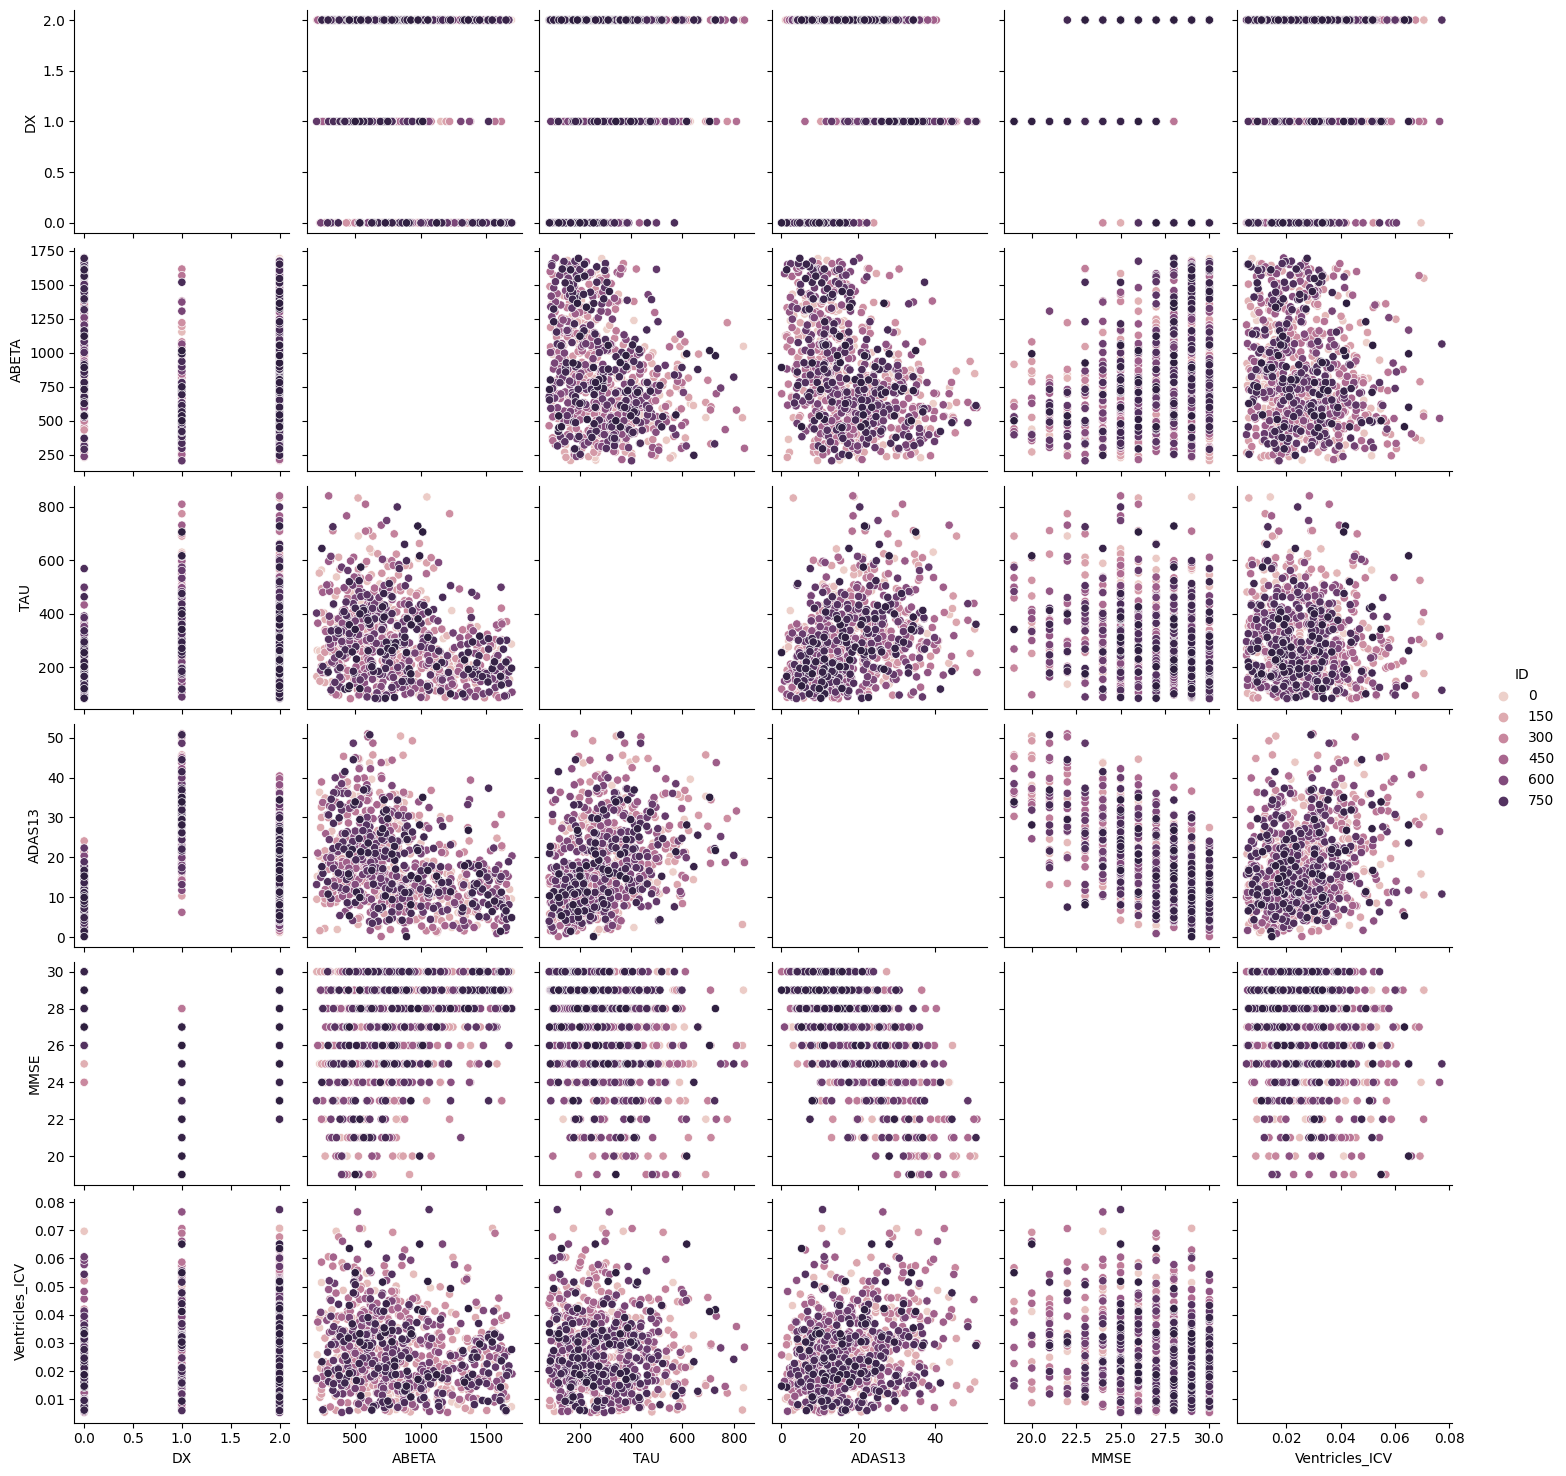

In [6]:
# A suggestion for visualising data: the pair plot
sn.pairplot(data=df_synth,hue='ID')

### Joint plots

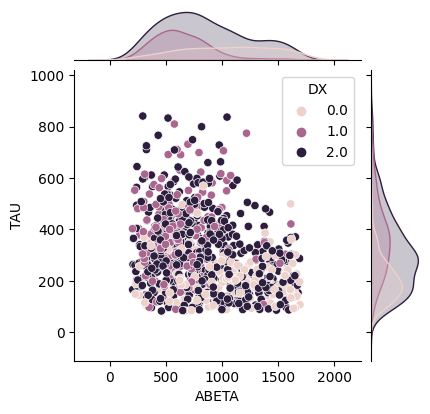

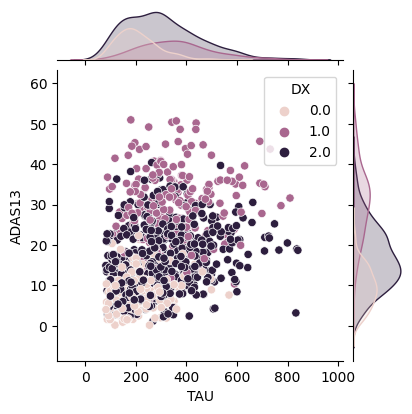

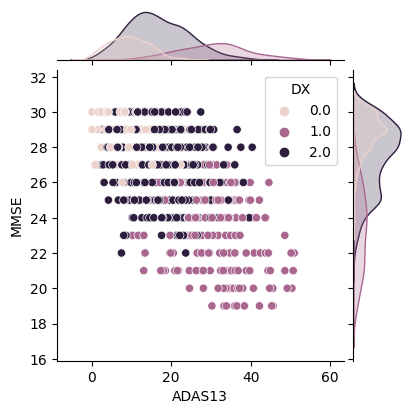

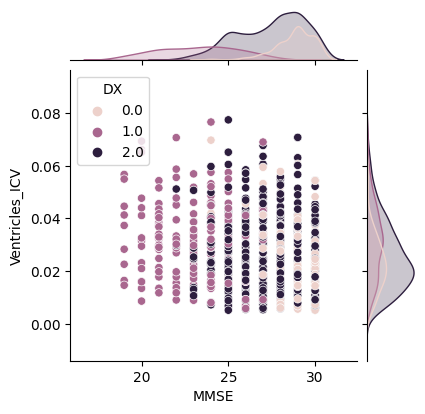

In [7]:
# Another suggestion for visualising data: joint plots
for k in range(X_synth.shape[1]-1):
    t = sn.jointplot(data=df_synth,x=biomarkers[k],y=biomarkers[k+1],hue='DX')
    t.fig.set_size_inches((4, 4))

<hr/>
<hr/>

## Demonstrating the Goldilocks framework for pySuStaIn

For each biomarker:
1. Convert to z-scores
   - Check the data visually
1. Calculate the empirical distribution
   - Check the data visually
1. Identify the Goldilocks Zone via sensible Event Horizons. Examples here are described below.
   1. Feature Selection: set minimum signal threshold, e.g., <br/>$z_{min} \equiv \arg\min CDF_{half-normal}(z)>0.5$
      - One might require that the median z-score in cases exceeds $z_{min}$ (otherwise, data from controls is somehow "more abnormal" than data from cases, suggesting an uninformative feature)
   1. SuStaIn Hyperparameter tuning: find maximum signal in the data, e.g., <br/>$z_{max} \equiv \arg\min EDF(z)>0.9$
1. Convert to `Z_vals` hyperparameter matrix, including a mid-point score
1. **FIXME: Demonstrate a feature that should not be included**

### 1. Convert to z-scores

- Uses robust statistics: median (not mean), median absolute deviation (not standard deviation)
- Uses known direction of abnormality (e.g., disease) to flip signs if needed (`ZscoreSustain` requires `z>0` to be the direction of abnormality)

In [8]:
# # Create goldilocks_dpm object
# gdpm = goldilocks_ZScoreSustain(
#     data = X,
#     classes = y,
#     direction_abnormal = direction_abnormal,
#     output_folder,
#     biomarker_labels=None,
#     robust_zscores=True
# )

# # 


In [9]:
X = X_synth
y = y_synth
N = X.shape[1]
[1 if np.median(X[y==1,k])>np.median(X[y==0,k]) else -1 for k in range(N)]

[-1, 1, 1, -1, 1]

In [10]:
np.median(X_synth[y==1,2])
# biomarkers

30.66581423699088

In [11]:
# Robust z-score
lambda_z = lambda x,c: (x - np.nanmedian(x[c,:],axis=0))/stats.median_abs_deviation(x[c,:],axis=0)
Z = lambda_z(X_synth,y_synth==0)

# Flip sign if needed
for k in range(len(biomarkers)):
    Z[:,k] = direction_abnormal[k]*Z[:,k]

In [12]:
def zscore_robust(X,y,ctrl_label,abnormal_direction):
    c = y==ctrl_label
    avg = np.nanmedian(X[c,:],axis=0)
    spread = stats.median_abs_deviation(X[c,:],axis=0)
    avg = np.tile(avg, (X.shape[0],1))
    spread = np.tile(spread, (X.shape[0],1))
    Z = abnormal_direction*(X - avg)/spread
    return Z, avg, spread
Z_, avg_, spread_ = zscore_robust(X_synth, y_synth, 0, direction_abnormal)

In [13]:
Z_not_controls = Z[y!=0,:]
y_not_controls = y[y!=0,]
np.around(np.nanmedian(Z_not_controls[y_not_controls==1,:],axis=0),2)

array([1.45, 3.04, 5.56, 6.  , 1.31])

In [14]:
lambda_z_min = lambda x,c: np.argmin(np.abs(stats.halfnorm.cdf(x)-c))
z_ = np.arange(-5,5,0.001) # +/- 3 sigma should cover most data from controls
t = 0.5
z_min = [ z_[lambda_z_min(z_,t)] ]*Z.shape[1]
z_min
print(f"Your data:\n medians: {np.around(np.nanmedian(Z_not_controls[y_not_controls==1,:],axis=0),2)}\n z_min:   {np.around(z_min,2)}")

Your data:
 medians: [1.45 3.04 5.56 6.   1.31]
 z_min:   [0.67 0.67 0.67 0.67 0.67]


#### Visualise your data!

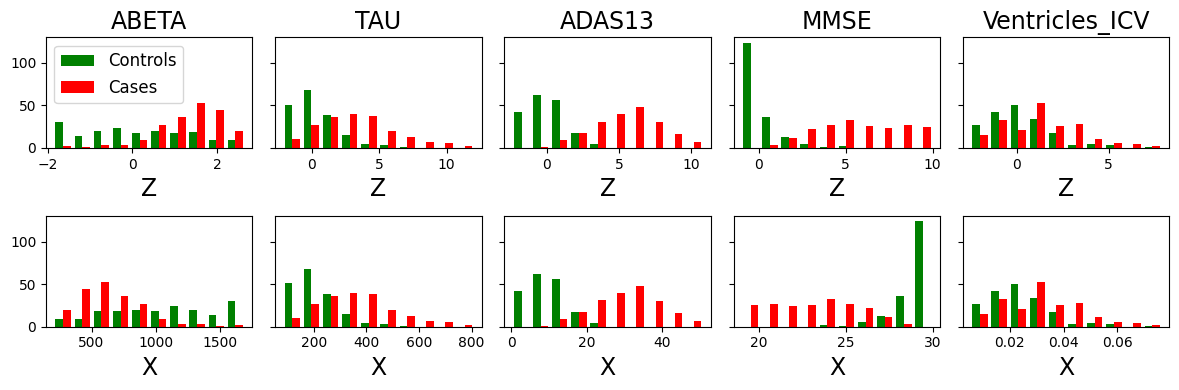

In [15]:
fig,ax = plt.subplots(2,len(biomarkers),figsize=(12,4),sharey=True)

for k in range(len(biomarkers)):
    ax[0,k].hist([Z[y_synth==0,k],Z[y_synth==1,k]],label=['Controls','Cases'],color=['g','r'])
    ax[0,k].set_title(biomarkers[k],fontsize=17)
    ax[0,k].set_xlabel('Z',fontsize=17)
    if k==0:
        ax[0,k].legend(fontsize=12)
    ax[1,k].hist([X_synth[y_synth==0,k],X_synth[y_synth==1,k]],label=['Controls','Cases'],color=['g','r'])
    ax[1,k].set_xlabel('X',fontsize=17)
fig.tight_layout()

### 2. Calculate empirical distribution

And of course plot!

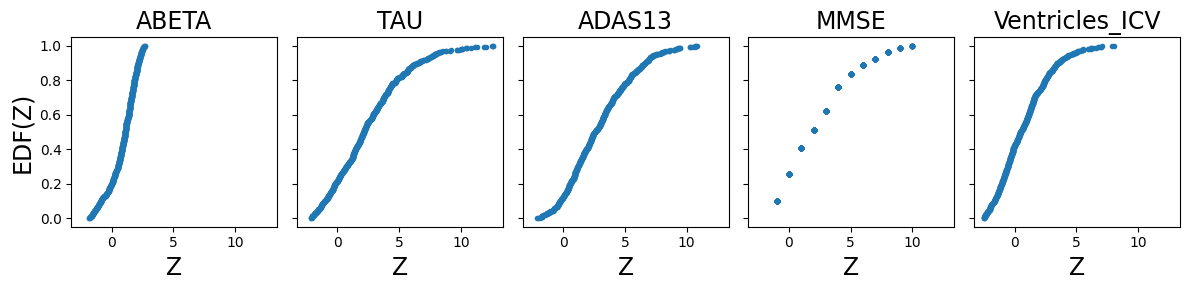

In [16]:
Z_not_controls = Z[y_synth>0,:]
y_not_controls = y_synth[y_synth>0]
EDF = np.empty(Z_not_controls.shape)
ecdf = []

fig,ax = plt.subplots(1,len(biomarkers),figsize=(12,3),sharey=True,sharex=True)
for k in range(len(biomarkers)):
    ecdf += [sm.distributions.empirical_distribution.ECDF(Z_not_controls[:,k])]
    EDF[:,k] = ecdf[k](Z_not_controls[:,k])
    ax[k].plot(Z_not_controls[:,k],EDF[:,k],'.')
    ax[k].set_title(biomarkers[k],fontsize=17)
    ax[k].set_xlabel('Z',fontsize=17)
ax[0].set_ylabel('EDF(Z)',fontsize=17)
fig.tight_layout()

### 3. Goldilocks Zone event horizons

1. $z_{min}$ based on half-normal CDF
1. $z_{max}$ based on z-score where EDF exceeds 0.9

In [17]:
print(" === Event Horizon 1: z_min === \n")

# Example minimum event threshold: 
# where the z score in non-controls exceeds at least half of the positive (abnormal) z-scores in controls,
# i.e., in data on the abnormal side (z>0), the median for controls is given by 
#    arg-min |CDF_{half-normal}(z_min)-0.5|
# which is where the positive z-scores are "more abnormal" than most controls
lambda_z_min = lambda x,c: np.argmin(np.abs(stats.halfnorm.cdf(x)-t))
z_ = np.arange(-3,3,0.001)

t = 0.5
z_min = [ z_[lambda_z_min(z_,t)] ]*len(biomarkers)
print("You might consider omitting features where the median in cases does not exceed z_min.")
print(f"Your data:\n medians: {np.around(np.nanmedian(Z_not_controls[y_not_controls==1,:],axis=0),2)}\n z_min:   {np.around(z_min,2)}")

# NOTE: this can be anything you want, but does it really make sense to have a z-score event lower than this?


 === Event Horizon 1: z_min === 

You might consider omitting features where the median in cases does not exceed z_min.
Your data:
 medians: [1.45 3.04 5.56 6.   1.31]
 z_min:   [0.67 0.67 0.67 0.67 0.67]


In [18]:
print(" === Event Horizon 2: z_max === ")

# Example maximum event threshold:
# Some proportion of data must exceed the maximum z-score event threshold, 
# or the model cannot be informative at this level.
# Here this proportion is set at 10%, i.e., the EDF must exceed 0.9, or:
#    arg-min |EDF_{half-normal}(z_min)-0.9|
edf_cutoff = 0.9
lambda_z_max = lambda e,t: np.argmin(np.abs(e-t))
z_max = [Z_not_controls[lambda_z_max(EDF[:,k],edf_cutoff),k] for k in range(EDF.shape[1])]
# z_max = [lambda_z_max(Z_not_controls[:,k],edf_cutoff) for k in range(Z_not_controls.shape[1])]

print("You should consider the maximum value your data can support, which will inform hyperparameters of ZscoreSustain.")
print(f" Here we've used an EDF cutoff of {edf_cutoff} to define `z_max`")
print(f"Your data:\n max: \t{np.around(np.nanmax(Z_not_controls[y_not_controls==1,:],axis=0),2)}\n z_max:\t{np.around(z_max,2)}")

event_horizons = [z_min,z_max]

 === Event Horizon 2: z_max === 
You should consider the maximum value your data can support, which will inform hyperparameters of ZscoreSustain.
 Here we've used an EDF cutoff of 0.9 to define `z_max`
Your data:
 max: [ 2.66 12.03 10.87 10.    7.9 ]
 z_max:   [2.15 6.45 6.61 6.   3.45]


### The Goldilocks Zones

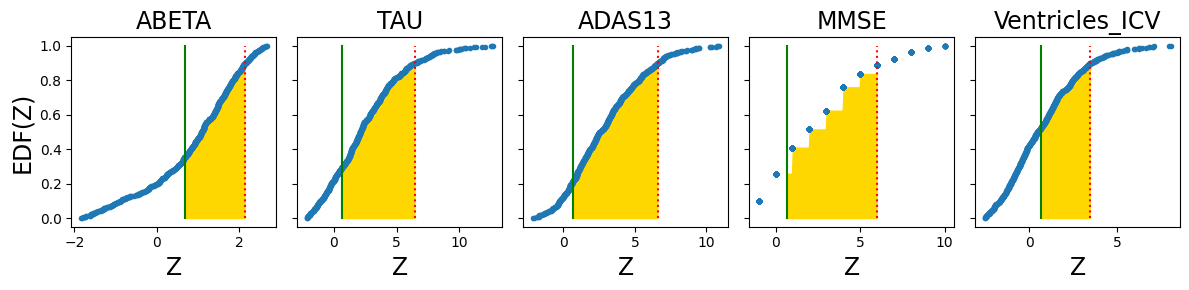

In [19]:
fig,ax = plt.subplots(1,len(biomarkers),figsize=(12,3),sharey=True)
for k in range(len(biomarkers)):
    ax[k].plot(Z_not_controls[:,k],EDF[:,k],'.')
    ax[k].set_title(biomarkers[k],fontsize=17)
    ax[k].set_xlabel('Z',fontsize=17)
    ax[k].plot([z_min[k],z_min[k]],[0,1],'g-')
    ax[k].plot([z_max[k],z_max[k]],[0,1],'r:')
    zed = np.arange(z_min[k],z_max[k],0.05)
    ax[k].fill_between(zed,ecdf[k](zed),color='gold')
    # ax[k].plot(Z_not_controls[:,k],np.abs(EDF[:,k]-edf_cutoff),'rx')
ax[0].set_ylabel('EDF(Z)',fontsize=17)
fig.tight_layout()

### Middle event thresholds for `ZscoreSustain`

Here we take a simple average, but you might want to do something more clever, e.g., something in log space like the logarithmic mean or the geometric mean.

In [20]:
midpoints = np.mean(event_horizons,axis=0)
print("If you want to add events between z_min and z_max, then you might take an average (for example).")
print(f" Here we get:\n  midpoints: {np.around(midpoints,2)}")

If you want to add events between z_min and z_max, then you might take an average (for example).
 Here we get:
  midpoints: [1.41 3.56 3.64 3.34 2.06]


In [21]:
# Round the event horizons
fraction_to_round = 0.25
event_horizons = np.concatenate(([[np.around(z/fraction_to_round)*fraction_to_round for z in z_min]],
                                 [[np.around(z/fraction_to_round)*fraction_to_round for z in z_max]]),axis=0)
print(f"event_horizons rounded: \n{event_horizons}")

# Round the midpoints
midpoints = np.around(midpoints/fraction_to_round)*fraction_to_round
print(f"midpoints rounded: \n{midpoints}")

event_horizons rounded: 
[[0.75 0.75 0.75 0.75 0.75]
 [2.25 6.5  6.5  6.   3.5 ]]
midpoints rounded: 
[1.5  3.5  3.75 3.25 2.  ]


In [22]:
print("The event horizons and midpoint event thresholds define sensible Z_vals hyperparameters for ZscoreSustain:")
# Z_vals, including midpoint event thresholds
Z_vals = np.concatenate(
    ( [event_horizons[0]],
      [midpoints],
      [event_horizons[1]] ), 
    axis=0
).T
print(f"Z_vals = \n{Z_vals}")

print("\n...and the rounded maximum values for each feature can inform Z_max hyperparameters for ZscoreSustain:")
# Z_max - simply round up
Z_max = [np.around(np.nanmax(Z_not_controls[:,k])/fraction_to_round)*fraction_to_round for k in range(Z_not_controls.shape[1])]

Z_max = np.array([Z_max]).T
print(f"Z_max = \n{Z_max}")

The event horizons and midpoint event thresholds define sensible Z_vals hyperparameters for ZscoreSustain:
Z_vals = 
[[0.75 1.5  2.25]
 [0.75 3.5  6.5 ]
 [0.75 3.75 6.5 ]
 [0.75 3.25 6.  ]
 [0.75 2.   3.5 ]]

...and the rounded maximum values for each feature can inform Z_max hyperparameters for ZscoreSustain:
Z_max = 
[[ 2.75]
 [12.75]
 [10.75]
 [10.  ]
 [ 8.  ]]


### NOTE: visual interpretation of subtype progression patterns estimated with `ZscoreSustain` are potentially simpler when `Z_vals` are the same for each biomarker.

This is because of the plotting method, which was developed using the default z-score event thresholds (1,2,3) for all features, with a single colour for each zscore (e.g., 1=red, 2=magenta, 3=blue).

For ease of visualisation, you might want to manually intervene and select a compromise, e.g.,
```
Z_vals = 
[[0.75 1.25 1.75]                       [[0.75  1.5 2. ]
 [0.75 3.   5.  ]                        [0.75  1.5 2. ]
 [0.75 3.75 6.75]       could become     [0.75  1.5 2. ]
 [0.75 3.5  6.  ]                        [0.75  1.5 2. ]
 [0.75 2.5  4.  ]]                       [0.75  1.5 2. ]]
```

Or you could improve the plotting module in `pySuStaIn`!

Now you're ready to run ZscoreSustain

# TODO

- [ ] Convert this example above to a simple `goldilocks-dpm.py` module and a `goldilocks-sustain.py` sub-class:
   - [ ] `ZscoreSustain`
   - [ ] `MixtureSustain`: KDE EBM
   - [ ] `OrdinalSustain`
   - [ ] Generic outputs for any other models
   - Outputs include:
      - Goldilocks Zone X_vals
      - `ZscoreSustain`: suggested Z_vals (including midpoints)
      - `MixtureSustain`: suggested 
      - Informational text: brief overview of the Goldilocks Zone concept/framework, description of the object/dictionary and the variables/values within, and the informational plots
      - Informational plots
      - Basic warnings, e.g., when data is outside the Goldilocks Zone, or the Zone is very small